In [21]:
import pandas as pd
import plotly.express as px

In [4]:
df_boston = pd.read_csv("Boston House Prices.csv")

In [5]:
df_boston

,Rooms,Distance,Value
0,6.575,4.0900,24.0
1,6.421,4.9671,21.6
2,7.185,4.9671,34.7
3,6.998,6.0622,33.4
4,7.147,6.0622,36.2
...,...,...,...
501,6.593,2.4786,22.4
502,6.120,2.2875,20.6
503,6.976,2.1675,23.9
504,6.794,2.3889,22.0


In [6]:
df_boston.describe()

,Rooms,Distance,Value
count,506.000000,506.000000,506.000000
mean,6.284634,3.795043,22.532806
std,0.702617,2.105710,9.197104
min,3.561000,1.129600,5.000000
25%,5.885500,2.100175,17.025000
50%,6.208500,3.207450,21.200000
75%,6.623500,5.188425,25.000000
max,8.780000,12.126500,50.000000


 # Linear Regression with StatsModels

In [8]:
import statsmodels.api as sm

# Simple Linear Regression

In [9]:
# Define the Dependent and Indepentdent variable
y = df_boston['Value']
x = df_boston['Rooms']

# Exploring the dataset

<Axes: xlabel='Rooms', ylabel='Value'>

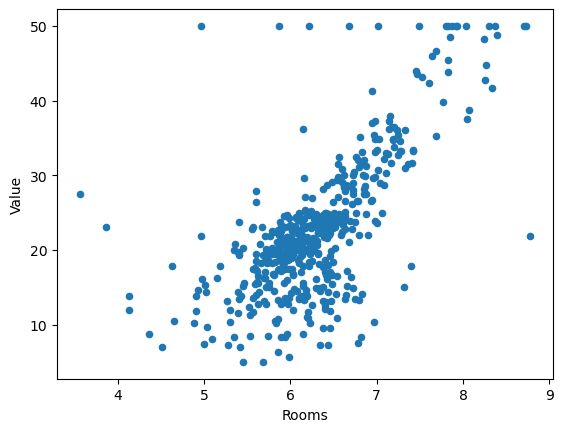

In [10]:
df_boston.plot(kind = 'scatter', x = 'Rooms', y = 'Value')

# Making a Regression line: Adding a constant and fitting the model

In [12]:
x = sm.add_constant(x)

In [38]:
#fit the model
lm = sm.OLS(y, x).fit()

pred_dataframe = pd.DataFrame({'Rooms':df_boston['Rooms'], 'Predicted':lm.predict(x), 'Actual':df_boston['Value']})
pred_dataframe['Error'] =  (pred_dataframe['Predicted'] -  pred_dataframe['Actual'])**2
MSE = pred_dataframe['Error'].sum()/pred_dataframe['Error'].count()
print(pred_dataframe)
print(MSE)

     Rooms  Predicted  Actual      Error
0    6.575  25.175746    24.0   1.382378
1    6.421  23.774021    21.6   4.726367
2    7.185  30.728032    34.7  15.776528
3    6.998  29.025938    33.4  19.132419
4    7.147  30.382152    36.2  33.847354
..     ...        ...     ...        ...
501  6.593  25.339584    22.4   8.641153
502  6.120  21.034286    20.6   0.188604
503  6.976  28.825691    23.9  24.262437
504  6.794  27.169108    22.0  26.719674
505  6.030  20.215096    11.9  69.140828

[506 rows x 4 columns]
43.60055177116956


# The Regression Table

In [16]:
lm.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                  Value   R-squared:                       0.484
Model:                            OLS   Adj. R-squared:                  0.483
Method:                 Least Squares   F-statistic:                     471.8
Date:                Fri, 27 Mar 2026   Prob (F-statistic):           2.49e-74
Time:                        07:44:57   Log-Likelihood:                -1673.1
No. Observations:                 506   AIC:                             3350.
Df Residuals:                     504   BIC:                             3359.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const        -34.6706      2.650    -13.084      0.000     -39.877     -29.465
Rooms          9.1021      0.419     21.722      0.000       8.279       9.925
==============================================================================
Omnibus:                      102.585   Durbin-Watson:                   0.684
Prob(Omnibus):                  0.000   Jarque-Bera (JB):              612.449
Skew:                           0.726   Prob(JB):                    1.02e-133
Kurtosis:                       8.190   Cond. No.                         58.4
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

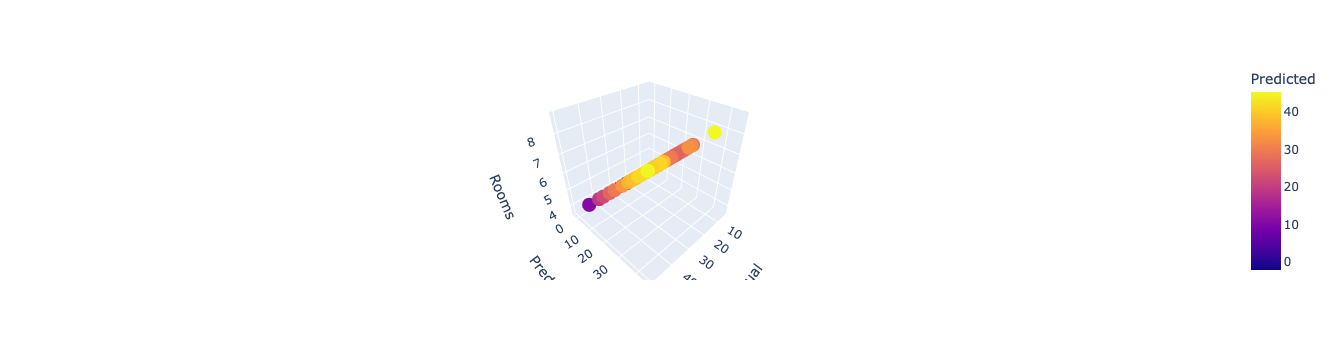

In [31]:
fig = px.scatter_3d(pred_dataframe, x='Actual', y='Predicted', z='Rooms',
              color='Predicted')
fig.show()

In [34]:
# Set up the linear Equation
y_pred = 9.1021*x['Rooms'] - 34.6706

# Plotting the Regression line

In [35]:
import seaborn as sns
import matplotlib.pyplot as plt

<Axes: xlabel='Rooms', ylabel='Value'>

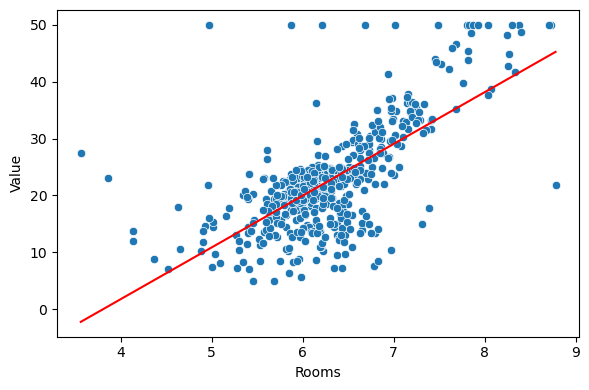

In [36]:
# plotting the data points
plt.figure(figsize=(6,4), tight_layout = True)
sns.scatterplot(x=x['Rooms'], y=y)

#plotting the line
sns.lineplot(x=x['Rooms'], y=y_pred, color = 'red')